# 06. Marketplace and Platform Interventions

Marketplace interventions are some of the hardest industry causal inference problems because the platform is not just changing a screen for isolated users. The platform is changing a market.

A buyer promotion can consume scarce seller capacity. A driver incentive can reduce rider wait times, but also change driver positioning and earnings. A ranking rule can move attention from one supplier to another. A fee change can change demand, supply, matching quality, and platform profit at the same time.

This notebook studies marketplace and platform interventions as causal systems with interference, equilibrium response, and multi-stakeholder tradeoffs. We will simulate:

- an individual-level A/B test that looks successful even though it does not increase total market output,
- a market-time switchback experiment for a supply incentive,
- a phased market rollout analyzed with event-study diagnostics,
- a decision memo that combines primary effects, guardrails, and unit economics.


## Learning Goals

By the end of this notebook, you should be able to:

- Explain why standard user-level A/B tests can be biased in two-sided marketplaces.
- Distinguish direct user effects from market-level or platform-level effects.
- Define marketplace estimands that match launch decisions.
- Use switchback designs for interventions that affect shared market conditions.
- Build metric readouts for demand, supply, platform economics, and guardrails.
- Diagnose carryover, congestion, and equilibrium risks.
- Translate marketplace evidence into a launch recommendation.


## 1. Setup

We will use pandas, numpy, statsmodels, scipy, seaborn, matplotlib, and Graphviz.


In [1]:
# Import the analysis, modeling, and plotting tools used throughout this notebook.
import warnings
warnings.filterwarnings("ignore")

from graphviz import Digraph
from IPython.display import Markdown, display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.special import expit
import statsmodels.formula.api as smf

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 80)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")


def summarize_binary_effect(df, outcome, treatment="treatment"):
    """Summarize the binary effect result.
    
    Inputs:
    - `df`: pandas DataFrame containing the observed or simulated data used by this estimator, plot, or diagnostic.
    - `outcome`: name of the observed outcome column whose causal contrast is being estimated.
    - `treatment`: name of the treatment-assignment column, usually coded as treated versus control.
    Returns: a compact pandas summary of the effect, posterior, or policy calculation."""
    summary = (
        df.groupby(treatment)[outcome]
        .agg(["mean", "count"])
        .rename(index={0: "Control", 1: "Treatment"})
    )
    diff = summary.loc["Treatment", "mean"] - summary.loc["Control", "mean"]
    return summary, diff


def regression_effect(model, term="treatment"):
    """Compute regression effect for the marketplace and platform interventions example.
    
    Inputs:
    - `model`: fitted statistical or machine-learning model whose coefficients or predictions are being used.
    - `term`: coefficient name whose estimate and uncertainty should be extracted.
    Returns: an effect-estimate summary for the causal comparison in the section."""
    estimate = model.params[term]
    se = model.bse[term]
    return pd.Series(
        {
            "estimate": estimate,
            "std_error": se,
            "ci_lower": estimate - 1.96 * se,
            "ci_upper": estimate + 1.96 * se,
            "p_value": model.pvalues[term],
        }
    )


def plot_coef_table(table, title, xlabel, reference=0, figsize=(8, 4)):
    """Plot the coef table display.
    
    Inputs:
    - `table`: estimate table with columns such as estimate, standard error, and confidence limits.
    - `title`: plot or graph title displayed above the figure.
    - `xlabel`: x-axis label used in the estimate plot.
    - `reference`: reference value shown as a vertical line, often the true or benchmark effect.
    - `figsize`: Matplotlib figure size passed to the plotting function.
    Returns: a Matplotlib figure or axes object that visualizes the causal estimates."""
    plot_df = table.sort_values("estimate")
    fig, ax = plt.subplots(figsize=figsize)
    ax.errorbar(
        x=plot_df["estimate"],
        y=plot_df.index,
        xerr=[
            plot_df["estimate"] - plot_df["ci_lower"],
            plot_df["ci_upper"] - plot_df["estimate"],
        ],
        fmt="o",
        color="#1f77b4",
        ecolor="#9ecae1",
        elinewidth=3,
        capsize=4,
    )
    ax.axvline(reference, color="#444444", linestyle="--", linewidth=1)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("")
    plt.tight_layout()
    return fig, ax


### Dataset and Experiment Setup

The marketplace examples use simulated platform data with buyers, sellers, searches, supply, and market-level activity. Treatments include seller priority, ranking changes, supply-side interventions, switchback assignment, and market rollout. Outcomes include seller performance, buyer satisfaction, conversion, search-level demand, and platform-level value.

The data is generated because marketplace interventions often violate independent-unit assumptions. Boosting one seller may reduce exposure for another seller. A ranking change may reallocate attention without creating new demand. A supply-side change can affect buyers, sellers, and congestion at the same time. Public datasets rarely contain the counterfactual exposure and demand needed to teach these mechanisms clearly. The synthetic setup lets the notebook distinguish value creation from redistribution, individual effects from platform effects, and user-level comparisons from market-level policy evidence.


## 2. Marketplace Interventions Are System Interventions

In a single-sided product experiment, we often hope that one user's outcome is unaffected by another user's assignment. In a marketplace, that hope is frequently wrong.

Consider a local delivery market. Customers request delivery, couriers provide capacity, the platform matches requests to couriers, and prices or incentives change behavior on both sides. If a treated customer receives priority matching, a control customer in the same market may wait longer. If treated couriers receive incentives, untreated customers may still benefit from extra supply.

The causal unit is often not just a user. It may be a market, a market-hour, a route, a search query, a budget pool, or a supply-demand graph.


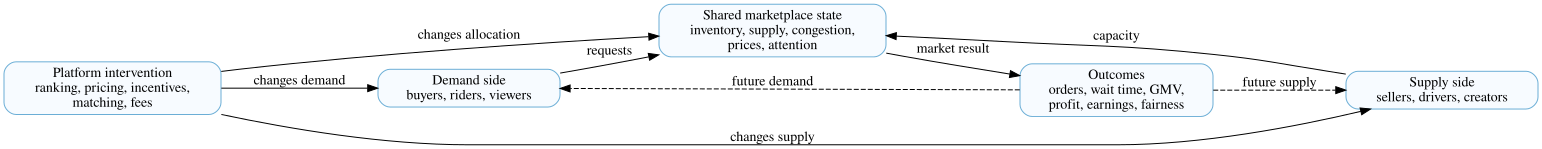

In [2]:
dot = Digraph("marketplace_system", graph_attr={"rankdir": "LR"})
dot.attr("node", shape="box", style="rounded,filled", fillcolor="#f7fbff", color="#6baed6")

dot.node("D", "Demand side\nbuyers, riders, viewers")
dot.node("P", "Platform intervention\nranking, pricing, incentives,\nmatching, fees")
dot.node("M", "Shared marketplace state\ninventory, supply, congestion,\nprices, attention")
dot.node("S", "Supply side\nsellers, drivers, creators")
dot.node("Y", "Outcomes\norders, wait time, GMV,\nprofit, earnings, fairness")

dot.edge("D", "M", label="requests")
dot.edge("S", "M", label="capacity")
dot.edge("P", "D", label="changes demand")
dot.edge("P", "S", label="changes supply")
dot.edge("P", "M", label="changes allocation")
dot.edge("M", "Y", label="market result")
dot.edge("Y", "D", label="future demand", style="dashed")
dot.edge("Y", "S", label="future supply", style="dashed")

dot


Li, Zhao, and Johari (2021) frame the target in two-sided marketplace experiments as the effect of launching an intervention platform-wide, not merely the difference between treated and control individuals inside a mixed experiment. Nandy, Venugopalan, and Lo (2021) make a related point for recommender systems in two-sided marketplaces: producer-side outcomes may violate the no-interference logic that is more plausible for isolated viewer-side outcomes.

The operating implication is direct:

> If the intervention changes shared supply, shared demand, shared ranking inventory, shared budget, or shared matching capacity, the experiment design must match that shared structure.


## 3. Metric Stack for Marketplace Decisions

Marketplace interventions usually need a multi-stakeholder metric stack. A primary metric alone can be misleading because a platform can improve one side by harming the other.


| stakeholder | metric | why_it_matters | typical_guardrail |
|---|---|---|---|
| Demand | Completed orders or rides | Measures whether the market produced more useful transactions. | Do not increase cancellation or wait time. |
| Demand | Wait time or search friction | Captures congestion and experience quality. | Do not hide quality degradation behind conversion. |
| Supply | Active suppliers or drivers | Measures whether the intervention attracts usable capacity. | Do not reduce earnings or overwork supply. |
| Platform | GMV and contribution profit | Separates transaction volume from net economics. | Incremental margin must exceed subsidy or fee cost. |
| Marketplace health | Liquidity, fairness, concentration | Checks whether gains are broad or only reallocated. | Do not starve long-tail suppliers or protected segments. |


## 4. Potential Outcomes With Interference

Under no interference, user $i$ has two potential outcomes:

$$
Y_i(1), \quad Y_i(0)
$$

In a marketplace, user $i$'s outcome may depend on the entire assignment vector:

$$
Y_i(\mathbf{W}) = Y_i(W_i, W_{-i})
$$

where $W_i$ is the assignment for user $i$ and $W_{-i}$ is the assignment for everyone else who can affect the same market.

This creates a different causal question. The narrow question is:

$$
E[Y_i(1) - Y_i(0)]
$$

the platform may need the global treatment effect:

$$
GTE = E[Y(\mathbf{1}) - Y(\mathbf{0})]
$$

That is the expected difference between launching the intervention everywhere versus launching it nowhere.

Hudgens and Halloran (2008) and Aronow and Samii (2017) provide general frameworks for causal inference when interference is present. In platform settings, this often means the analyst must explicitly define the exposure mapping, cluster boundary, or market-level treatment policy.


| estimand | question | risk |
|---|---|---|
| Direct user effect | What happens to treated users relative to untreated users in the same market? | Can capture reallocation and miss total marketplace lift. |
| Spillover effect | What happens to untreated users when others are treated? | Often invisible in standard dashboards. |
| Market-level effect | What happens when a whole market-period is treated? | Requires fewer, larger units and careful power analysis. |
| Global treatment effect | What happens if the platform launches the intervention everywhere? | May require modeling or designs that approximate full launch conditions. |
| Net policy value | Does incremental contribution exceed subsidies, incentives, and risk? | Requires economics, not just causal lift. |


## 5. Simulation 1: A User-Level A/B Test With Shared Supply

Imagine a delivery marketplace testing priority matching for treated customers. Treated customers are moved to the front of the matching queue. The experiment randomizes customers within the same market-hour.

This sounds like a normal A/B test, but there is a fixed amount of supply in each market-hour. If treated customers get priority, control customers compete for the remaining capacity. The treated-control contrast can look positive even if the platform creates no additional completed orders.

We will simulate exactly that.


In [5]:
# Generate the teaching data and keep the causal quantities needed for diagnostics.
def simulate_priority_marketplace(seed=20260430, n_market_hours=700):
    """Simulate the priority marketplace data-generating process.
    
    Inputs:
    - `seed`: integer random seed that makes the simulation or model split reproducible.
    - `n_market_hours`: number of marketplace-hour observations in the platform simulation.
    Returns: a pandas DataFrame with generated covariates, treatment or policy variables, outcomes, and teaching diagnostics for this scenario."""
    rng = np.random.default_rng(seed)
    markets = ["Austin", "Boston", "Chicago", "Denver", "Miami", "Phoenix", "Portland", "Seattle"]
    dayparts = ["morning", "midday", "evening", "late"]
    daypart_factor = {"morning": 0.85, "midday": 1.00, "evening": 1.35, "late": 0.70}
    market_demand = {m: rng.uniform(70, 130) for m in markets}
    market_supply_ratio = {m: rng.uniform(0.62, 0.86) for m in markets}

    rows = []
    for h in range(n_market_hours):
        market = rng.choice(markets)
        daypart = rng.choice(dayparts, p=[0.25, 0.30, 0.30, 0.15])
        demand_mu = market_demand[market] * daypart_factor[daypart] * rng.lognormal(0, 0.08)
        demand = max(20, int(rng.poisson(demand_mu)))
        capacity_mu = demand_mu * market_supply_ratio[market] * rng.lognormal(0, 0.07)
        capacity = max(8, min(demand, int(rng.poisson(capacity_mu))))

        treatment = rng.binomial(1, 0.50, size=demand)
        request_quality = rng.normal(0, 1, size=demand)
        order_value = rng.lognormal(mean=3.50 + 0.08 * request_quality, sigma=0.28, size=demand)

        no_priority_order = rng.permutation(demand)
        completed_no_priority = np.zeros(demand, dtype=int)
        completed_no_priority[no_priority_order[:capacity]] = 1

        priority_score = 10 * treatment + rng.normal(0, 0.001, size=demand)
        priority_order = np.argsort(-priority_score)
        completed_priority = np.zeros(demand, dtype=int)
        completed_priority[priority_order[:capacity]] = 1

        scarcity = demand / max(capacity, 1)
        wait = (
            4
            + 11 * scarcity
            - 4.5 * treatment * completed_priority
            + 7.5 * (1 - treatment) * (1 - completed_priority)
            + rng.normal(0, 2.2, size=demand)
        )
        wait = np.clip(wait, 2, 60)

        for i in range(demand):
            rows.append(
                {
                    "market_hour": h,
                    "market": market,
                    "daypart": daypart,
                    "request_id": f"{h}-{i}",
                    "demand": demand,
                    "capacity": capacity,
                    "treatment": treatment[i],
                    "completed": completed_priority[i],
                    "completed_no_priority": completed_no_priority[i],
                    "wait_minutes": wait[i],
                    "order_value": order_value[i],
                    "gmv": completed_priority[i] * order_value[i],
                    "gmv_no_priority": completed_no_priority[i] * order_value[i],
                }
            )

    return pd.DataFrame(rows)


df_priority = simulate_priority_marketplace()
df_priority.head()


,market_hour,market,daypart,request_id,demand,capacity,treatment,completed,completed_no_priority,wait_minutes,order_value,gmv,gmv_no_priority
0,0,Austin,midday,0-0,102,72,1,1,1,14.640,38.776,38.776,38.776
1,0,Austin,midday,0-1,102,72,1,1,1,13.713,25.652,25.652,25.652
2,0,Austin,midday,0-2,102,72,0,1,0,18.745,30.869,30.869,0.000
3,0,Austin,midday,0-3,102,72,1,1,1,13.484,25.340,25.340,25.340
4,0,Austin,midday,0-4,102,72,1,1,1,15.422,63.604,63.604,63.604


The treatment does not create more drivers or more restaurant capacity. It only changes allocation priority within each market-hour.

If the platform compares treated customers to control customers, the estimate answers whether priority helped the users who got priority relative to users who did not. That is a real direct effect. It is a different question from whether the marketplace completed more orders.


In [6]:
priority_summary = (
    df_priority.groupby("treatment")
    .agg(
        requests=("request_id", "count"),
        completion_rate=("completed", "mean"),
        no_priority_completion_rate=("completed_no_priority", "mean"),
        avg_wait=("wait_minutes", "mean"),
        avg_gmv=("gmv", "mean"),
    )
    .rename(index={0: "Control users", 1: "Treated users"})
)

priority_summary["completion_vs_no_priority"] = (
    priority_summary["completion_rate"] - priority_summary["no_priority_completion_rate"]
)

priority_summary


,requests,completion_rate,no_priority_completion_rate,avg_wait,avg_gmv,completion_vs_no_priority
treatment,,,,,,
Control users,34977,0.482,0.743,23.209,16.675,-0.261
Treated users,35303,0.997,0.739,14.802,34.515,0.258


The treated users look better than their no-priority counterfactual, while control users look worse. This is the signature of reallocating scarce capacity.

Now compare total market output under priority against the no-priority counterfactual.


In [7]:
# Assemble the summary table used to interpret the causal comparison.
market_hour_totals = (
    df_priority.groupby("market_hour")
    .agg(
        market=("market", "first"),
        daypart=("daypart", "first"),
        demand=("demand", "first"),
        capacity=("capacity", "first"),
        completed_priority=("completed", "sum"),
        completed_no_priority=("completed_no_priority", "sum"),
        gmv_priority=("gmv", "sum"),
        gmv_no_priority=("gmv_no_priority", "sum"),
    )
    .assign(
        completion_rate_priority=lambda d: d["completed_priority"] / d["demand"],
        completion_rate_no_priority=lambda d: d["completed_no_priority"] / d["demand"],
        incremental_completed=lambda d: d["completed_priority"] - d["completed_no_priority"],
        incremental_gmv=lambda d: d["gmv_priority"] - d["gmv_no_priority"],
    )
)

market_output = pd.Series(
    {
        "completed_orders_with_priority": market_hour_totals["completed_priority"].sum(),
        "completed_orders_without_priority": market_hour_totals["completed_no_priority"].sum(),
        "incremental_completed_orders": market_hour_totals["incremental_completed"].sum(),
        "mean_market_hour_gmv_difference": market_hour_totals["incremental_gmv"].mean(),
    }
)

market_output


completed_orders_with_priority      52,069.000
completed_orders_without_priority   52,069.000
incremental_completed_orders             0.000
mean_market_hour_gmv_difference          2.357
dtype: float64

Completed orders did not increase because priority does not create capacity. It changes who gets served.

This is not a bug in the simulation. It is the point. A standard individual-level A/B test can estimate a positive direct effect while the platform-level effect is zero or even negative after fairness, supplier, cancellation, or long-term retention costs.


## 6. Naive User-Level Readout

Let us estimate a user-level treatment effect with market-hour fixed effects. This controls for demand shocks and supply shocks common to everyone in the same market-hour.

The model is:

$$
Y_{ih} = \alpha_h + \tau W_{ih} + \epsilon_{ih}
$$

where $h$ indexes market-hour.


In [8]:
priority_completion_model = smf.ols(
    "completed ~ treatment + C(market_hour)",
    data=df_priority,
).fit(
    cov_type="cluster",
    cov_kwds={"groups": df_priority["market_hour"]},
)

priority_wait_model = smf.ols(
    "wait_minutes ~ treatment + C(market_hour)",
    data=df_priority,
).fit(
    cov_type="cluster",
    cov_kwds={"groups": df_priority["market_hour"]},
)

priority_effects = pd.DataFrame(
    {
        "Completion rate": regression_effect(priority_completion_model),
        "Wait minutes": regression_effect(priority_wait_model),
    }
).T

priority_effects


,estimate,std_error,ci_lower,ci_upper,p_value
Completion rate,0.520,0.010,0.500,0.540,0.000
Wait minutes,-8.452,0.079,-8.606,-8.298,0.000


The regression says priority increases completion and reduces wait time for treated users. That is true for the direct effect among users competing inside the same supply pool.

But this estimate should not be sold as marketplace lift. The intervention shifted capacity from control users to treated users. For launch, leadership would need to ask:

- Is the reallocation intentional?
- Are treated users higher value, more at risk, or strategically important?
- What happens to users who lose access?
- Does the platform create more total transactions, better matching quality, or better long-run retention?


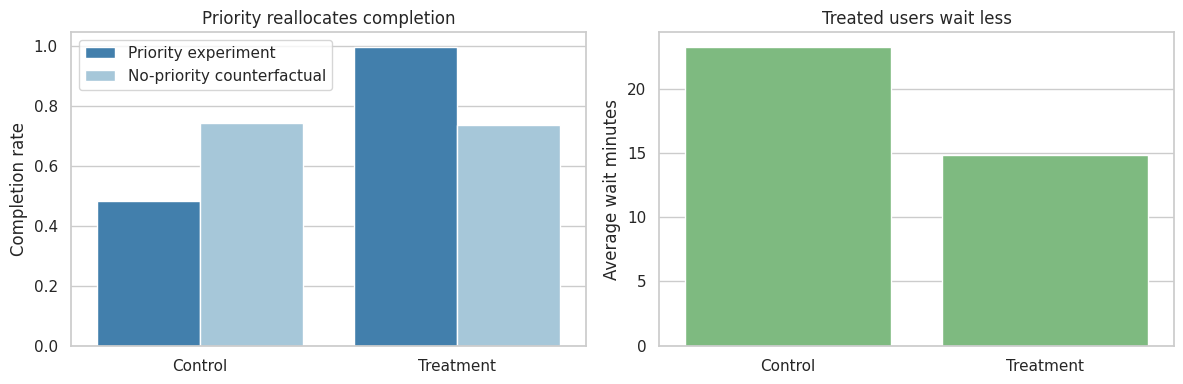

In [9]:
# Build the visualization for the estimates or diagnostics computed above.
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

plot_data = (
    df_priority.groupby("treatment")
    .agg(
        observed_completion=("completed", "mean"),
        no_priority_completion=("completed_no_priority", "mean"),
        wait_minutes=("wait_minutes", "mean"),
    )
    .rename(index={0: "Control", 1: "Treatment"})
    .reset_index(names="group")
)

completion_long = plot_data.melt(
    id_vars="group",
    value_vars=["observed_completion", "no_priority_completion"],
    var_name="scenario",
    value_name="completion_rate",
)
completion_long["scenario"] = completion_long["scenario"].map(
    {
        "observed_completion": "Priority experiment",
        "no_priority_completion": "No-priority counterfactual",
    }
)

sns.barplot(
    data=completion_long,
    x="group",
    y="completion_rate",
    hue="scenario",
    ax=axes[0],
    palette=["#3182bd", "#9ecae1"],
)
axes[0].set_title("Priority reallocates completion")
axes[0].set_xlabel("")
axes[0].set_ylabel("Completion rate")
axes[0].legend(title="")

sns.barplot(
    data=plot_data,
    x="group",
    y="wait_minutes",
    ax=axes[1],
    color="#74c476",
)
axes[1].set_title("Treated users wait less")
axes[1].set_xlabel("")
axes[1].set_ylabel("Average wait minutes")

plt.tight_layout()
plt.show()


## 7. Better Estimand for This Intervention

For priority matching, the platform has at least three possible decision questions:

1. **Targeting question:** Should high-value or high-risk users receive priority when capacity is scarce?
2. **Marketplace output question:** Does priority increase total completed orders, GMV, or retention?
3. **Fairness question:** Who loses capacity when priority is turned on?

The first question can be studied with individual randomization if the target is a direct reallocation effect. The second and third require market-level analysis, explicit spillover measurement, or a design that compares whole market states.


| claim | supported_by_user_ab | supported_by_market_totals | decision_use |
|---|---|---|---|
| Priority helps treated users | Yes | Yes, as a direct reallocation claim | Targeting or queue policy. |
| Priority increases total completed orders | No | No in this simulation | Do not use the direct effect as platform lift. |
| Priority is fair or acceptable | No | Only partly | Requires segment and harm analysis. |


## 8. Simulation 2: A Market-Time Switchback for Supply Incentives

Now consider a different intervention: a temporary supply incentive that encourages more drivers or sellers to be active in a market-period.

This intervention affects everyone in the market-period. If more supply enters the market, treated and control customers in the same hour cannot be isolated. A cleaner design is a switchback:

- define market-periods, such as city by daypart,
- randomize the whole market-period to treatment or control,
- switch treatment status over time,
- compare treated and control periods with market and time controls.

Bojinov, Simchi-Levi, and Zhao (2020) study switchback experiment design. Li, Johari, and Wager (2023) discuss experimentation under stochastic congestion and note the relevance of switchback designs for service systems such as ride-sharing and delivery.


In [11]:
# Generate the teaching data and keep the causal quantities needed for diagnostics.
def simulate_supply_switchback(seed=8675309, n_markets=10, n_days=28):
    """Simulate the supply switchback data-generating process.
    
    Inputs:
    - `seed`: integer random seed that makes the simulation or model split reproducible.
    - `n_markets`: number of markets or platform regions in the simulation.
    - `n_days`: number of daily periods in the switchback or time-indexed simulation.
    Returns: a pandas DataFrame with generated covariates, treatment or policy variables, outcomes, and teaching diagnostics for this scenario."""
    rng = np.random.default_rng(seed)
    markets = [f"Market {i+1:02d}" for i in range(n_markets)]
    dayparts = ["morning", "midday", "evening", "late"]
    daypart_factor = {"morning": 0.90, "midday": 1.00, "evening": 1.35, "late": 0.72}
    market_base_demand = {m: rng.uniform(85, 150) for m in markets}
    market_base_supply = {m: rng.uniform(0.62, 0.84) for m in markets}
    market_order_value = {m: rng.uniform(30, 48) for m in markets}

    rows = []
    for market in markets:
        for day in range(n_days):
            weekday = day % 7
            weekend = 1 if weekday in [5, 6] else 0
            for part_index, daypart in enumerate(dayparts):
                forecast_demand = (
                    market_base_demand[market]
                    * daypart_factor[daypart]
                    * (1 + 0.10 * weekend)
                    * rng.lognormal(0, 0.06)
                )

                treatment = rng.binomial(1, 0.50)
                demand = max(10, int(rng.poisson(forecast_demand)))
                control_supply_mean = forecast_demand * market_base_supply[market]
                active_supply = max(
                    5,
                    int(rng.poisson(control_supply_mean * (1 + 0.18 * treatment))),
                )

                supply_demand_ratio = active_supply / max(demand, 1)
                completion_prob = expit(-1.10 + 2.25 * supply_demand_ratio)
                completion_prob = float(np.clip(completion_prob, 0.05, 0.98))
                completed_orders = rng.binomial(demand, completion_prob)

                avg_wait = np.clip(
                    34 - 24 * supply_demand_ratio + rng.normal(0, 2.6),
                    2.5,
                    45,
                )
                cancel_rate = expit(-3.10 + 1.65 * (1 - supply_demand_ratio) + rng.normal(0, 0.10))

                avg_order_value = market_order_value[market] * rng.lognormal(0, 0.04)
                gmv = completed_orders * avg_order_value
                take_rate = 0.19
                incentive_cost = treatment * (4.25 * active_supply + 0.65 * completed_orders)
                contribution_profit = take_rate * gmv - incentive_cost
                supplier_earnings = 0.78 * gmv + treatment * 4.25 * active_supply

                rows.append(
                    {
                        "market": market,
                        "day": day,
                        "weekday": weekday,
                        "daypart": daypart,
                        "part_index": part_index,
                        "period": day * len(dayparts) + part_index,
                        "treatment": treatment,
                        "forecast_demand": forecast_demand,
                        "demand": demand,
                        "active_supply": active_supply,
                        "supply_demand_ratio": supply_demand_ratio,
                        "completed_orders": completed_orders,
                        "completion_rate": completed_orders / demand,
                        "avg_wait": avg_wait,
                        "cancel_rate": cancel_rate,
                        "gmv": gmv,
                        "incentive_cost": incentive_cost,
                        "contribution_profit": contribution_profit,
                        "supplier_earnings": supplier_earnings,
                        "supplier_earnings_per_active": supplier_earnings / active_supply,
                    }
                )

    df = pd.DataFrame(rows)
    df = df.sort_values(["market", "period"]).reset_index(drop=True)
    df["prev_treatment"] = df.groupby("market")["treatment"].shift(1).fillna(0).astype(int)
    return df


df_switchback = simulate_supply_switchback()
df_switchback.head()


,market,day,weekday,daypart,part_index,period,treatment,forecast_demand,demand,active_supply,supply_demand_ratio,completed_orders,completion_rate,avg_wait,cancel_rate,gmv,incentive_cost,contribution_profit,supplier_earnings,supplier_earnings_per_active,prev_treatment
0,Market 01,0,0,morning,0,0,1,92.406,111,67,0.604,61,0.550,19.295,0.080,"2,131.755",324.400,80.633,"1,947.519",29.067,0
1,Market 01,0,0,midday,1,1,1,97.867,101,88,0.871,71,0.703,16.818,0.062,"2,607.974",420.150,75.365,"2,408.220",27.366,1
2,Market 01,0,0,evening,2,2,1,143.885,135,117,0.867,92,0.681,9.129,0.047,"3,268.698",557.050,64.003,"3,046.834",26.041,1
3,Market 01,0,0,late,3,3,0,70.137,67,43,0.642,34,0.507,19.628,0.084,"1,241.748",0.000,235.932,968.563,22.525,1
4,Market 01,1,1,morning,0,4,1,100.787,107,79,0.738,67,0.626,17.825,0.055,"2,216.197",379.300,41.777,"2,064.384",26.131,0


The market-period is the unit of assignment. Every rider and driver in a treated market-period is exposed to the incentive-induced market condition.

Before estimating effects, check whether randomization balanced pre-treatment demand forecasts.


In [12]:
balance = (
    df_switchback.groupby("treatment")
    .agg(
        periods=("period", "count"),
        forecast_demand=("forecast_demand", "mean"),
        demand=("demand", "mean"),
        active_supply=("active_supply", "mean"),
    )
    .rename(index={0: "Control periods", 1: "Treatment periods"})
)

balance.loc["Difference"] = balance.loc["Treatment periods"] - balance.loc["Control periods"]
balance


,periods,forecast_demand,demand,active_supply
treatment,,,,
Control periods,558.000,123.386,123.961,91.622
Treatment periods,562.000,119.995,119.735,104.358
Difference,4.000,-3.391,-4.226,12.736


Active supply is post-treatment, so we expect it to move. Forecast demand is the main balance check because it is determined before treatment assignment.

Now estimate treatment effects with market, daypart, and day fixed effects:

$$
Y_{mtp} = \alpha_m + \delta_t + \gamma_p + \tau W_{mtp} + \beta \widehat{D}_{mtp} + \epsilon_{mtp}
$$

where $m$ is market, $t$ is day, and $p$ is daypart.


In [13]:
# Fit the models for this section and assemble the estimates used in the discussion.
def switchback_effect(outcome):
    """Compute switchback effect for the marketplace and platform interventions example.
    
    Inputs:
    - `outcome`: name of the observed outcome column whose causal contrast is being estimated.
    Returns: an effect-estimate summary for the causal comparison in the section."""
    model = smf.ols(
        f"{outcome} ~ treatment + forecast_demand + C(market) + C(day) + C(daypart)",
        data=df_switchback,
    ).fit(
        cov_type="cluster",
        cov_kwds={"groups": df_switchback["market"]},
    )
    return regression_effect(model, "treatment")


outcomes = {
    "Active supply": "active_supply",
    "Completed orders": "completed_orders",
    "Completion rate": "completion_rate",
    "Average wait minutes": "avg_wait",
    "Cancellation rate": "cancel_rate",
    "GMV": "gmv",
    "Incentive cost": "incentive_cost",
    "Contribution profit": "contribution_profit",
    "Supplier earnings per active": "supplier_earnings_per_active",
}

switchback_results = pd.DataFrame(
    {label: switchback_effect(col) for label, col in outcomes.items()}
).T

switchback_results


,estimate,std_error,ci_lower,ci_upper,p_value
Active supply,15.861,1.127,13.652,18.069,0.000
Completed orders,7.309,0.323,6.676,7.943,0.000
Completion rate,0.064,0.004,0.056,0.071,0.000
Average wait minutes,-3.091,0.259,-3.598,-2.583,0.000
Cancellation rate,-0.011,0.001,-0.013,-0.010,0.000
GMV,301.024,19.934,261.952,340.095,0.000
Incentive cost,505.281,30.116,446.254,564.308,0.000
Contribution profit,-448.087,27.001,-501.008,-395.165,0.000
Supplier earnings per active,2.330,0.112,2.111,2.550,0.000


The treatment increases active supply and completed orders, reduces wait time, and changes contribution profit after accounting for incentive cost.

This table is closer to the launch decision than a user-level A/B test because the treatment is assigned at the level where the intervention actually operates: the market-period.


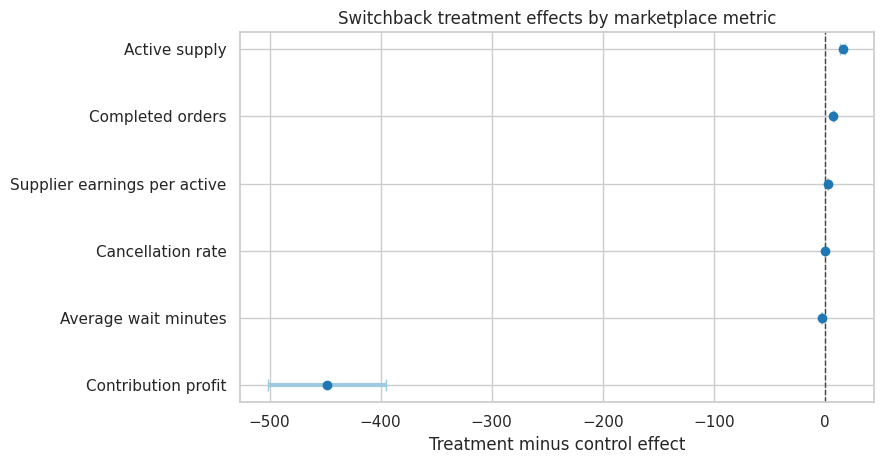

In [14]:
plot_table = switchback_results.loc[
    [
        "Active supply",
        "Completed orders",
        "Average wait minutes",
        "Cancellation rate",
        "Contribution profit",
        "Supplier earnings per active",
    ]
]

plot_coef_table(
    plot_table,
    title="Switchback treatment effects by marketplace metric",
    xlabel="Treatment minus control effect",
    figsize=(9, 4.8),
)
plt.show()


The coefficient plot makes the stakeholder tradeoff visible. A treatment can be operationally attractive if it increases completed orders and reduces wait time. It may still be a bad business decision if the incentive cost overwhelms incremental margin, or a bad marketplace decision if supplier earnings fall.


In [15]:
period_readout = (
    df_switchback.groupby("treatment")
    .agg(
        completed_orders=("completed_orders", "mean"),
        gmv=("gmv", "mean"),
        incentive_cost=("incentive_cost", "mean"),
        contribution_profit=("contribution_profit", "mean"),
        supplier_earnings_per_active=("supplier_earnings_per_active", "mean"),
        avg_wait=("avg_wait", "mean"),
    )
    .rename(index={0: "Control periods", 1: "Treatment periods"})
)

period_readout.loc["Raw difference"] = (
    period_readout.loc["Treatment periods"] - period_readout.loc["Control periods"]
)

period_readout


,completed_orders,gmv,incentive_cost,contribution_profit,supplier_earnings_per_active,avg_wait
treatment,,,,,,
Control periods,78.622,"3,232.508",0.000,614.176,27.690,16.075
Treatment periods,83.447,"3,405.381",497.760,149.262,29.826,13.087
Raw difference,4.825,172.873,497.760,-464.914,2.137,-2.988


## 9. Unit Economics: Incremental Contribution

The causal effect on GMV is not the same as the causal effect on profit. A subsidy or incentive can buy growth that is not economically sustainable.

For each market-period:

$$
Contribution = TakeRate \times GMV - IncentiveCost
$$

The decision should compare incremental contribution, not only incremental orders.


In [16]:
# Assemble the summary table used to interpret the causal comparison.
completed_effect = switchback_results.loc["Completed orders", "estimate"]
gmv_effect = switchback_results.loc["GMV", "estimate"]
cost_effect = switchback_results.loc["Incentive cost", "estimate"]
profit_effect = switchback_results.loc["Contribution profit", "estimate"]
wait_effect = switchback_results.loc["Average wait minutes", "estimate"]

unit_economics = pd.DataFrame(
    [
        {
            "component": "Incremental completed orders per market-period",
            "estimate": completed_effect,
            "interpretation": "Operational lift created by extra supply.",
        },
        {
            "component": "Incremental GMV per market-period",
            "estimate": gmv_effect,
            "interpretation": "Gross transaction value before platform economics.",
        },
        {
            "component": "Incremental incentive cost per market-period",
            "estimate": cost_effect,
            "interpretation": "Direct cost of inducing supply.",
        },
        {
            "component": "Incremental contribution profit per market-period",
            "estimate": profit_effect,
            "interpretation": "Net platform economics after incentive cost.",
        },
        {
            "component": "Incremental wait minutes",
            "estimate": wait_effect,
            "interpretation": "Negative is good for demand-side experience.",
        },
    ]
)

unit_economics


,component,estimate,interpretation
0,Incremental completed orders per market-period,7.309,Operational lift created by extra supply.
1,Incremental GMV per market-period,301.024,Gross transaction value before platform econom...
2,Incremental incentive cost per market-period,505.281,Direct cost of inducing supply.
3,Incremental contribution profit per market-period,-448.087,Net platform economics after incentive cost.
4,Incremental wait minutes,-3.091,Negative is good for demand-side experience.


The key lesson is not that incentives are always good or bad. The lesson is that marketplace experiments must report the full path:

$$
Incentive \rightarrow Supply \rightarrow Matching \rightarrow CompletedOrders \rightarrow GMV \rightarrow Contribution
$$

Skipping the middle of that path makes it hard to distinguish a real marketplace improvement from a paid volume increase.


## 10. Carryover and Lagged Effects

Switchback designs are powerful. Treatment in one period can affect later periods and bias them.

Examples:

- drivers stay online after an incentive ends,
- sellers change inventory after a promotion,
- buyers delay purchases in anticipation of future discounts,
- ranking changes retrain user behavior or supplier strategy.

A simple diagnostic is to include lagged treatment. This diagnostic cannot rule out carryover. It reveals whether the previous period is predictive after controlling for current treatment.


In [17]:
carryover_model = smf.ols(
    "completed_orders ~ treatment + prev_treatment + forecast_demand + C(market) + C(day) + C(daypart)",
    data=df_switchback,
).fit(
    cov_type="cluster",
    cov_kwds={"groups": df_switchback["market"]},
)

carryover_readout = pd.DataFrame(
    {
        "Current treatment": regression_effect(carryover_model, "treatment"),
        "Previous period treatment": regression_effect(carryover_model, "prev_treatment"),
    }
).T

carryover_readout


,estimate,std_error,ci_lower,ci_upper,p_value
Current treatment,7.317,0.330,6.670,7.963,0.000
Previous period treatment,-0.872,0.392,-1.640,-0.104,0.026


If lagged treatment is large, the analyst should revisit the design:

- lengthen treatment periods,
- add washout periods,
- randomize at a slower cadence,
- model dynamic effects directly,
- use a rollout design with longer treatment periods.


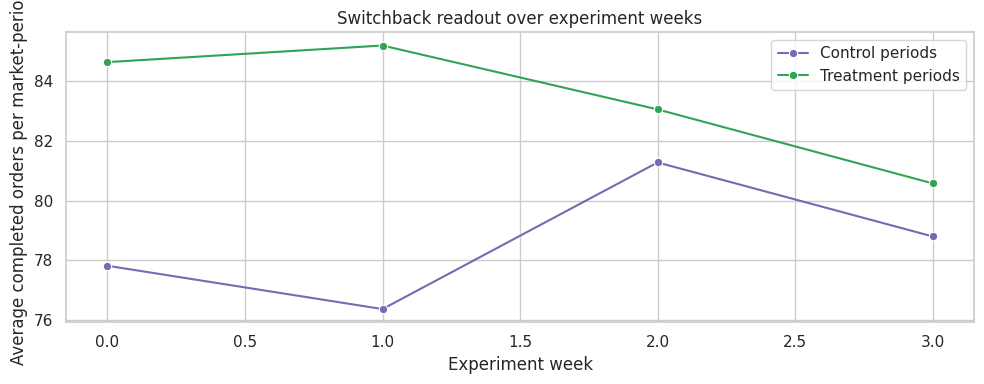

In [18]:
fig, ax = plt.subplots(figsize=(10, 4))

weekly = (
    df_switchback.assign(week=lambda d: d["day"] // 7)
    .groupby(["week", "treatment"])
    .agg(completed_orders=("completed_orders", "mean"))
    .reset_index()
)
weekly["group"] = weekly["treatment"].map({0: "Control periods", 1: "Treatment periods"})

sns.lineplot(
    data=weekly,
    x="week",
    y="completed_orders",
    hue="group",
    marker="o",
    ax=ax,
    palette=["#756bb1", "#31a354"],
)
ax.set_title("Switchback readout over experiment weeks")
ax.set_xlabel("Experiment week")
ax.set_ylabel("Average completed orders per market-period")
ax.legend(title="")
plt.tight_layout()
plt.show()


## 11. Simulation 3: Phased Market Rollout

Some platform changes cannot switch back quickly. Examples include:

- a major matching algorithm,
- seller fee changes,
- trust and safety policy changes,
- a new fulfillment promise,
- large UI changes that users would notice.

For these, a phased market rollout may be more realistic. A rollout design compares markets before and after launch, using never-treated or later-treated markets as comparisons.

This is weaker than a clean randomized switchback if rollout timing is chosen strategically, but it is often the evidence available during real launches.


In [19]:
# Generate the teaching data and keep the causal quantities needed for diagnostics.
def simulate_market_rollout(seed=314159, n_markets=36, n_weeks=24):
    """Simulate the market rollout data-generating process.
    
    Inputs:
    - `seed`: integer random seed that makes the simulation or model split reproducible.
    - `n_markets`: number of markets or platform regions in the simulation.
    - `n_weeks`: number of weekly periods in the simulated market, pricing, or rollout data.
    Returns: a pandas DataFrame with generated covariates, treatment or policy variables, outcomes, and teaching diagnostics for this scenario."""
    rng = np.random.default_rng(seed)
    markets = [f"City {i+1:02d}" for i in range(n_markets)]
    cohorts = np.array([8, 12, 16, 999])
    cohort_prob = np.array([0.25, 0.25, 0.25, 0.25])
    rollout_week = dict(zip(markets, rng.choice(cohorts, size=n_markets, p=cohort_prob)))
    market_fe = {m: rng.normal(0, 5) for m in markets}

    rows = []
    for market in markets:
        base = 68 + market_fe[market]
        adoption_week = rollout_week[market]
        for week in range(n_weeks):
            treated = int(week >= adoption_week)
            event_time = week - adoption_week if adoption_week < 900 else np.nan
            seasonal = 2.5 * np.sin(2 * np.pi * week / 12)
            trend = 0.18 * week
            dynamic_effect = 0
            if treated:
                dynamic_effect = 1.4 + 0.45 * min(max(event_time, 0), 5)
            liquidity_index = base + seasonal + trend + dynamic_effect + rng.normal(0, 2.4)
            rows.append(
                {
                    "market": market,
                    "week": week,
                    "rollout_week": adoption_week,
                    "treated": treated,
                    "event_time": event_time,
                    "liquidity_index": liquidity_index,
                    "never_treated": int(adoption_week == 999),
                }
            )

    return pd.DataFrame(rows)


df_rollout = simulate_market_rollout()
df_rollout.head()


,market,week,rollout_week,treated,event_time,liquidity_index,never_treated
0,City 01,0,999,0,NaN,74.523,1
1,City 01,1,999,0,NaN,70.855,1
2,City 01,2,999,0,NaN,77.479,1
3,City 01,3,999,0,NaN,77.515,1
4,City 01,4,999,0,NaN,73.634,1


The outcome is a liquidity index: a composite score of search-to-order conversion, wait time, and cancellation performance. Higher is better.

We estimate an event study with market and week fixed effects. The omitted category is one week before rollout, $k=-1$.


In [20]:
# Fit the models for this section and assemble the estimates used in the discussion.
event_window = list(range(-6, 8))
event_window.remove(-1)

event_cols = []
for k in event_window:
    col = f"event_m{abs(k)}" if k < 0 else f"event_p{k}"
    df_rollout[col] = ((df_rollout["event_time"] == k).astype(int)).fillna(0)
    event_cols.append(col)

formula = "liquidity_index ~ " + " + ".join(event_cols) + " + C(market) + C(week)"
event_model = smf.ols(formula, data=df_rollout).fit(
    cov_type="cluster",
    cov_kwds={"groups": df_rollout["market"]},
)

event_results = []
for k, col in zip(event_window, event_cols):
    est = event_model.params[col]
    se = event_model.bse[col]
    event_results.append(
        {
            "event_time": k,
            "estimate": est,
            "std_error": se,
            "ci_lower": est - 1.96 * se,
            "ci_upper": est + 1.96 * se,
        }
    )

event_results = pd.DataFrame(event_results)
event_results


,event_time,estimate,std_error,ci_lower,ci_upper
0,-6,-0.714,0.504,-1.702,0.273
1,-5,-1.202,0.532,-2.246,-0.159
2,-4,-0.858,0.532,-1.901,0.186
3,-3,0.273,0.505,-0.716,1.262
4,-2,-1.137,0.540,-2.195,-0.078
5,0,-0.311,0.584,-1.456,0.834
6,1,0.747,0.527,-0.286,1.780
7,2,1.343,0.565,0.236,2.450
8,3,1.535,0.538,0.480,2.590
9,4,-0.053,0.516,-1.064,0.957


Pre-period coefficients should be close to zero if treated markets were on similar trends before rollout. Post-period coefficients show how the effect evolves after launch.

platform changes can shift outcomes on multiple sides of the market, so the causal readout should track cross-side effects and congestion.

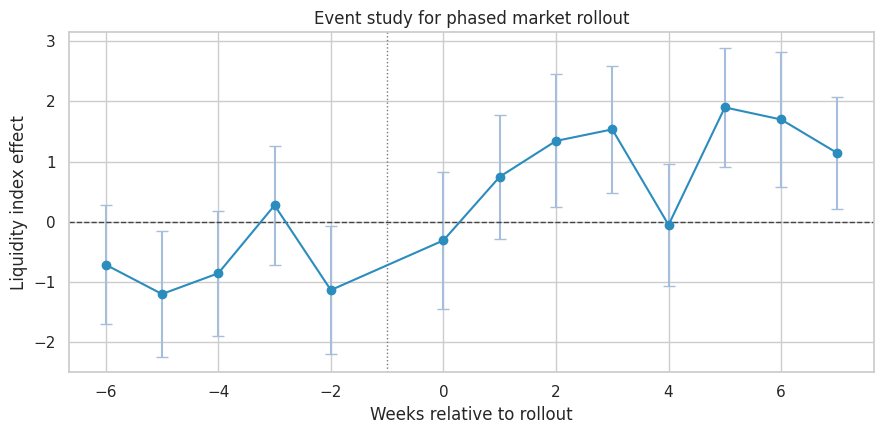

In [21]:
fig, ax = plt.subplots(figsize=(9, 4.5))

ax.errorbar(
    event_results["event_time"],
    event_results["estimate"],
    yerr=[
        event_results["estimate"] - event_results["ci_lower"],
        event_results["ci_upper"] - event_results["estimate"],
    ],
    fmt="o-",
    color="#2b8cbe",
    ecolor="#a6bddb",
    capsize=4,
)
ax.axhline(0, color="#444444", linestyle="--", linewidth=1)
ax.axvline(-1, color="#777777", linestyle=":", linewidth=1)
ax.set_title("Event study for phased market rollout")
ax.set_xlabel("Weeks relative to rollout")
ax.set_ylabel("Liquidity index effect")
plt.tight_layout()
plt.show()


The event study is useful for launch monitoring, but it depends on assumptions:

- rollout timing should not be based on unobserved shocks to the outcome,
- comparison markets should be credible,
- the intervention should not spill across market boundaries,
- pre-trends should be inspected before interpreting post-treatment effects,
- later-treated markets should be valid controls before their own rollout.

In many marketplace organizations, the best practical workflow is:

1. use switchbacks when the treatment is reversible and market-period exposure is natural,
2. use phased rollout with holdout markets when the treatment is not reversible,
3. use structural or simulation models when full-launch equilibrium effects differ from any partial experiment.


## 12. Choosing the Right Design

The unit of randomization should follow the mechanism of interference.


| intervention | shared_resource | candidate_design | watch_out_for |
|---|---|---|---|
| Buyer coupon | Seller inventory or delivery capacity | Geo or market-level experiment | Substitution, budget constraints, and delayed purchases. |
| Priority matching | Queue position and supply capacity | Market-period experiment or explicit reallocation study | Direct effect can hide harm to non-prioritized users. |
| Driver or seller incentive | Active supply | Switchback by market-period | Carryover and supplier learning. |
| Ranking algorithm | Attention and exposure | Cluster, query, market, or producer-aware design | Producer-side interference and concentration. |
| Marketplace fee change | Demand, supply, and long-run participation | Phased rollout with holdouts | Equilibrium response and selection into markets. |


## 13. Marketplace Experiment Checklist

Before launching a marketplace intervention, ask the following questions.


| area | question | good_answer |
|---|---|---|
| Estimand | Is the decision about direct user effects, market output, or global launch? | The target estimand is written before looking at results. |
| Interference | Who shares supply, demand, budget, inventory, ranking slots, or attention? | The randomization unit contains the main interference path. |
| Power | How many independent market-periods or clusters do we really have? | Inference clusters match treatment assignment. |
| Carryover | Can treatment in one period affect later periods? | The design includes washout, slower cadence, or lag diagnostics. |
| Economics | Do incremental contribution and long-term value exceed cost? | The readout includes cost, margin, and stakeholder guardrails. |
| Fairness | Which users or suppliers lose exposure, orders, or earnings? | Segment-level harm is measured, not averaged away. |


## 14. Decision Memo

A strong marketplace readout is not only a table of p-values. It is a decision document that explains the mechanism, estimand, metrics, economics, and risks.


In [24]:
profit_ci = switchback_results.loc["Contribution profit", ["ci_lower", "ci_upper"]]
completed_ci = switchback_results.loc["Completed orders", ["ci_lower", "ci_upper"]]
wait_ci = switchback_results.loc["Average wait minutes", ["ci_lower", "ci_upper"]]
earnings_ci = switchback_results.loc["Supplier earnings per active", ["ci_lower", "ci_upper"]]

recommendation = "Ramp with monitoring" if profit_effect > 0 and completed_effect > 0 and wait_effect < 0 else "Do not ramp yet"

memo = f'''
### Marketplace Intervention Decision Memo

**Intervention:** temporary supply incentive by market-period.

**Design:** switchback randomized at the market-daypart level with market, day, and daypart fixed effects.

**Primary marketplace effect:** completed orders increased by **{completed_effect:,.2f}** per market-period
with a 95% confidence interval from **{completed_ci['ci_lower']:,.2f}** to **{completed_ci['ci_upper']:,.2f}**.

**Demand-side guardrail:** average wait changed by **{wait_effect:,.2f}** minutes
with a 95% confidence interval from **{wait_ci['ci_lower']:,.2f}** to **{wait_ci['ci_upper']:,.2f}**.
Negative values are better.

**Supply-side guardrail:** supplier earnings per active supplier changed by **{switchback_results.loc['Supplier earnings per active', 'estimate']:,.2f}**
with a 95% confidence interval from **{earnings_ci['ci_lower']:,.2f}** to **{earnings_ci['ci_upper']:,.2f}**.

**Economics:** contribution profit changed by **{profit_effect:,.2f}** per market-period after incentive cost.

**Recommendation:** **{recommendation}.**

**Caveats:** keep monitoring carryover, supplier fatigue, market-level heterogeneity, and whether the measured experiment effect generalizes to a larger rollout where all neighboring markets may be treated.
'''

display(Markdown(memo))



### Marketplace Intervention Decision Memo

**Intervention:** temporary supply incentive by market-period.

**Design:** switchback randomized at the market-daypart level with market, day, and daypart fixed effects.

**Primary marketplace effect:** completed orders increased by **7.31** per market-period
with a 95% confidence interval from **6.68** to **7.94**.

**Demand-side guardrail:** average wait changed by **-3.09** minutes
with a 95% confidence interval from **-3.60** to **-2.58**.
Negative values are better.

**Supply-side guardrail:** supplier earnings per active supplier changed by **2.33**
with a 95% confidence interval from **2.11** to **2.55**.

**Economics:** contribution profit changed by **-448.09** per market-period after incentive cost.

**Recommendation:** **Do not ramp yet.**

**Caveats:** keep monitoring carryover, supplier fatigue, market-level heterogeneity, and whether the measured experiment effect generalizes to a larger rollout where all neighboring markets may be treated.


## 15. Common Failure Modes

Marketplace causal analysis often fails in predictable ways:

- **Wrong unit of analysis:** users are randomized when markets, routes, or budget pools are the real units.
- **Direct effect sold as global lift:** treated users improve because controls lose access to scarce resources.
- **Post-treatment conditioning:** analysis conditions on being matched, seeing inventory, or accepting a trip after treatment has already affected those events.
- **Ignoring supply response:** demand-side interventions change supplier behavior, earnings, and future availability.
- **Ignoring equilibrium:** a treatment that works at 5% exposure may not work at 100% exposure.
- **Under-clustered uncertainty:** standard errors treat millions of users as independent when only dozens of markets were randomized.
- **Metric myopia:** GMV rises while contribution profit, wait time, cancellations, or fairness worsen.


## 16. Exercises

1. Modify the priority simulation so treated users have higher order value. When does reallocation become economically rational?
2. Add a fairness metric to the priority simulation. Which customer segment loses the most capacity?
3. Change the supply incentive cost. At what cost does the switchback recommendation flip?
4. Add carryover to the switchback simulation by making supply depend on previous treatment. How does the current-period estimate change?
5. In the phased rollout simulation, assign early rollout to markets with improving pre-trends. What happens to the event-study pre-period coefficients?
6. Design an experiment for a seller ranking change where the platform cares about both buyer conversion and seller exposure concentration.


## 17. Key Takeaways

- Marketplace interventions are system interventions because users share supply, demand, inventory, budget, ranking slots, and attention.
- User-level A/B tests can estimate direct reallocation effects that do not equal platform-level lift.
- Write the estimand before choosing the design: direct effect, spillover effect, market-level effect, global treatment effect, or net policy value.
- Switchback designs are useful when market-period treatment is reversible and interference is mostly contained within market-periods.
- Phased rollout designs are useful when switching back is infeasible, but they require careful pre-trend and holdout logic.
- Marketplace readouts should include demand outcomes, supply outcomes, platform economics, and guardrails.


## References

Aronow, P. M., & Samii, C. (2017). Estimating average causal effects under general interference, with application to a social network experiment. *The Annals of Applied Statistics, 11*(4), 1912-1947. [https://doi.org/10.1214/16-AOAS1005](https://doi.org/10.1214/16-AOAS1005)

Bojinov, I., Simchi-Levi, D., & Zhao, J. (2020). Design and analysis of switchback experiments. *arXiv*. [https://doi.org/10.48550/arxiv.2009.00148](https://doi.org/10.48550/arxiv.2009.00148)

Hudgens, M. G., & Halloran, M. E. (2008). Toward causal inference with interference. *Journal of the American Statistical Association, 103*(482), 832-842. [https://doi.org/10.1198/016214508000000292](https://doi.org/10.1198/016214508000000292)

Li, H., Zhao, G., Johari, R., & Weintraub, G. Y. (2021). Interference, bias, and variance in two-sided marketplace experimentation: Guidance for platforms. *arXiv*. [https://doi.org/10.48550/arxiv.2104.12222](https://doi.org/10.48550/arxiv.2104.12222)

Li, S., Johari, R., & Wager, S. (2023). Experimenting under stochastic congestion. *arXiv*. [https://doi.org/10.48550/arxiv.2302.12093](https://doi.org/10.48550/arxiv.2302.12093)

Nandy, P., Venugopalan, D., & Lo, C. (2021). A/B testing for recommender systems in a two-sided marketplace. *arXiv*. [https://doi.org/10.48550/arxiv.2106.00762](https://doi.org/10.48550/arxiv.2106.00762)

Pouget-Abadie, J., Saint-Jacques, G., Saveski, M., Duan, W., Ghosh, S., Xu, Y., & Airoldi, E. M. (2019). Testing for arbitrary interference on experimentation platforms. *Biometrika, 106*(4), 929-940. [https://doi.org/10.1093/biomet/asz047](https://doi.org/10.1093/biomet/asz047)
